<a href="https://colab.research.google.com/github/shriya-0802/OsteoArthritis/blob/main/DENSENET_UPDATED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# RECTIFIED DENSENET121 – 3 CLASSES, FAST & ACCURATE
# =============================================================================
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from google.colab import drive



In [2]:
drive.mount('/content/drive/')


Mounted at /content/drive/


In [3]:
# =============================================================================
# PATHS & CLASSES
# =============================================================================
train_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/train'
test_path  = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/test'
valid_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/val'
original_classes = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']



In [4]:
# =============================================================================
# 1. CLAHE PREPROCESSING (COMMENT OUT TO SKIP AND SAVE TIME)
# =============================================================================
def apply_clahe(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

def preprocess_dataset(data_path):
    for class_folder in os.listdir(data_path):
        class_path = os.path.join(data_path, class_folder)
        if os.path.isdir(class_path):
            for fname in os.listdir(class_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_path, fname)
                    img = cv2.imread(img_path)
                    if img is not None:
                        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        enhanced = apply_clahe(img_rgb)
                        cv2.imwrite(img_path, cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))

# Uncomment the next lines if you want CLAHE (takes ~5 minutes)
# print("Applying CLAHE to all images...")
# for path in [train_path, test_path, valid_path]:
#     preprocess_dataset(path)
# print("CLAHE done.")


In [5]:
# =============================================================================
# 2. BUILD DATAFRAMES AND RELABEL TO 3 CLASSES
# =============================================================================
def make_df(data_path):
    filepaths, labels = [], []
    for klass in os.listdir(data_path):
        klass_path = os.path.join(data_path, klass)
        if os.path.isdir(klass_path):
            label = original_classes[int(klass)]
            for fname in os.listdir(klass_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    filepaths.append(os.path.join(klass_path, fname))
                    labels.append(label)
    return pd.DataFrame({'filepaths': filepaths, 'labels': labels})

train_df = make_df(train_path)
test_df  = make_df(test_path)
valid_df = make_df(valid_path)

# Relabel: Healthy + Doubtful + Minimal → Healthy
def relabel(label):
    if label in ['Healthy', 'Doubtful', 'Minimal']:
        return 'Healthy'
    return label   # Moderate or Severe

for df in [train_df, test_df, valid_df]:
    df['labels'] = df['labels'].apply(relabel)

print("Class distribution after relabeling (train):")
print(train_df['labels'].value_counts())


Class distribution after relabeling (train):
labels
Healthy     4858
Moderate     757
Severe       173
Name: count, dtype: int64


In [6]:
# =============================================================================
# 3. BALANCE TRAINING DATA (500 PER CLASS)
# =============================================================================
def balance_data(df, target=500):
    balanced = []
    for label in df['labels'].unique():
        sub = df[df['labels'] == label]
        if len(sub) < target:
            sampled = sub.sample(n=target, replace=True, random_state=42)
        else:
            sampled = sub.sample(n=target, random_state=42)
        balanced.append(sampled)
    return pd.concat(balanced, ignore_index=True)

train_df_balanced = balance_data(train_df, target=500)
print("\nBalanced training distribution:")
print(train_df_balanced['labels'].value_counts())




Balanced training distribution:
labels
Healthy     500
Severe      500
Moderate    500
Name: count, dtype: int64


In [7]:
# =============================================================================
# 4. DATA GENERATORS
# =============================================================================
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df_balanced,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

valid_gen = val_test_datagen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

classes = list(train_gen.class_indices.keys())
class_count = len(classes)
print(f"\nClasses: {classes}")


Found 1500 validated image filenames belonging to 3 classes.
Found 826 validated image filenames belonging to 3 classes.
Found 1656 validated image filenames belonging to 3 classes.

Classes: ['Healthy', 'Moderate', 'Severe']


In [8]:
# =============================================================================
# 5. CLASS WEIGHTS
# =============================================================================
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df_balanced['labels']),
    y=train_df_balanced['labels']
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


In [9]:
# =============================================================================
# 6. BUILD MODEL (TWO‑STAGE TRAINING)
# =============================================================================
def build_model(num_classes):
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3),
        pooling='max'
    )
    base.trainable = False
    x = base.output
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=base.input, outputs=outputs)
    return model, base


In [10]:
model, base_model = build_model(class_count)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])


In [12]:
# Callbacks (more aggressive to save time)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/Colab Notebooks/best_densenet_3class.keras',
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)



In [13]:
# =============================================================================
# STAGE 1: Train top layers (fewer epochs)
# =============================================================================
print("\n" + "="*60)
print("STAGE 1: Training top layers (frozen DenseNet121)")
print("="*60)

history1 = model.fit(
    train_gen, epochs=10,   # reduced from 20
    validation_data=valid_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)



STAGE 1: Training top layers (frozen DenseNet121)
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3419 - loss: 1.3723
Epoch 1: val_accuracy improved from None to 0.41889, saving model to /content/drive/MyDrive/Colab Notebooks/best_densenet_3class.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_densenet_3class.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 663s 14s/step - accuracy: 0.3893 - loss: 1.2782 - val_accuracy: 0.4189 - val_loss: 0.9238 - learning_rate: 0.0010
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4623 - loss: 1.0788
Epoch 2: val_accuracy improved from 0.41889 to 0.82809, saving model to /content/drive/MyDrive/Colab Notebooks/best_densenet_3class.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_densenet_3class.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 404s 9s/step - accuracy: 0.4740 - loss: 1.0777 - val_accuracy: 0.8281 - val_loss: 0.5804 - learning_rate: 0.0010
Epoch 3/10
47/47 ━━━━━━━━━━

In [14]:
# =============================================================================
# STAGE 2: Fine‑tune last 50 layers
# =============================================================================
print("\n" + "="*60)
print("STAGE 2: Fine‑tuning last 50 layers")
print("="*60)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history2 = model.fit(
    train_gen, epochs=15,   # reduced from 30
    validation_data=valid_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)




STAGE 2: Fine‑tuning last 50 layers
Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4544 - loss: 1.0526
Epoch 1: val_accuracy improved from 0.82809 to 0.83051, saving model to /content/drive/MyDrive/Colab Notebooks/best_densenet_3class.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_densenet_3class.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 456s 9s/step - accuracy: 0.4733 - loss: 1.0280 - val_accuracy: 0.8305 - val_loss: 0.6179 - learning_rate: 1.0000e-05
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4524 - loss: 1.0634
Epoch 2: val_accuracy did not improve from 0.83051
47/47 ━━━━━━━━━━━━━━━━━━━━ 429s 9s/step - accuracy: 0.4633 - loss: 1.0434 - val_accuracy: 0.8305 - val_loss: 0.6482 - learning_rate: 1.0000e-05
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5031 - loss: 1.0015
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 3: val_accuracy did not improve from 0.83051
47/47 ━

In [15]:
# Load best weights
model.load_weights('/content/drive/MyDrive/Colab Notebooks/best_densenet_3class.keras')



In [16]:
# =============================================================================
# 7. EVALUATION
# =============================================================================
def evaluate(model, test_gen, classes):
    print("\n" + "="*60)
    print("FINAL EVALUATION ON TEST SET")
    print("="*60)
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    acc = np.mean(y_pred == y_true) * 100
    print(f"\nTest Accuracy: {acc:.2f}%")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix (Acc: {acc:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))
    return acc



FINAL EVALUATION ON TEST SET
52/52 ━━━━━━━━━━━━━━━━━━━━ 431s 8s/step

Test Accuracy: 81.58%


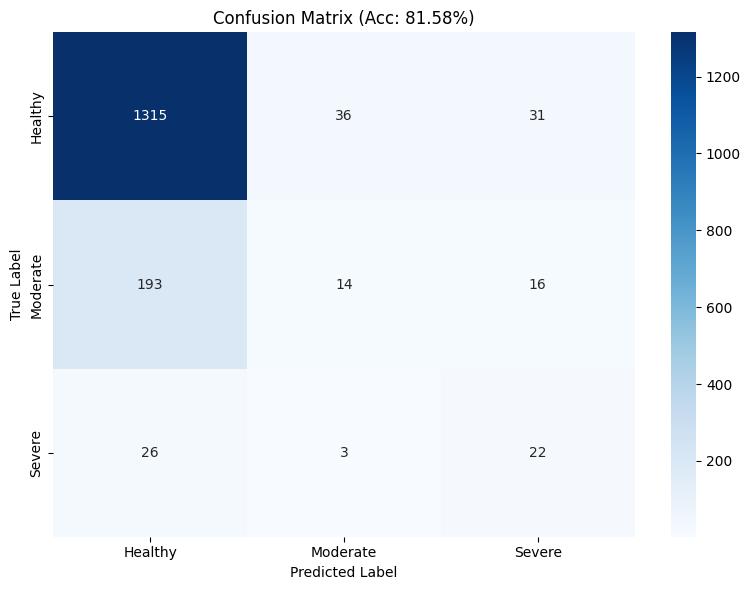


Classification Report:
              precision    recall  f1-score   support

     Healthy     0.8572    0.9515    0.9019      1382
    Moderate     0.2642    0.0628    0.1014       223
      Severe     0.3188    0.4314    0.3667        51

    accuracy                         0.8158      1656
   macro avg     0.4801    0.4819    0.4567      1656
weighted avg     0.7608    0.8158    0.7776      1656



In [17]:
test_acc = evaluate(model, test_gen, classes)



In [18]:
# =============================================================================
# 8. SAVE FINAL MODEL
# =============================================================================
final_path = f'/content/drive/MyDrive/Colab Notebooks/DenseNet121_3class_{test_acc:.2f}%.keras'
model.save(final_path)
print(f"\nModel saved to: {final_path}")

print("\n" + "="*60)
print(f"TRAINING COMPLETE – Test Accuracy: {test_acc:.2f}%")
print("="*60)


Model saved to: /content/drive/MyDrive/Colab Notebooks/DenseNet121_3class_81.58%.keras

TRAINING COMPLETE – Test Accuracy: 81.58%
